# Eksperimen Supervised Machine Learning (SML) - Nurul-Fitriah

## 1. Perkenalan Dataset
Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

Sumber Dataset:
Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (Kaggle, UCI ML Repository, Open Data) atau data primer yang Anda kumpulkan sendiri.

---
### Informasi Dataset Credit Scoring (Dataset Eksperimen):
Eksperimen ini menggunakan dataset **Credit Scoring**. Dataset ini dikembangkan secara sintetis untuk mensimulasikan data pengajuan pinjaman bank. Dataset ini memiliki beberapa masalah umum data dunia nyata seperti data kosong (missing values), outlier pada variabel umur dan pendapatan, baris duplikat, dan variabel kategorikal.

**Variabel/Fitur pada Dataset:**
- `customer_id`: ID unik nasabah (identifikasi)
- `age`: Umur nasabah
- `annual_income`: Pendapatan tahunan nasabah
- `credit_score`: Skor kredit nasabah (berkisar antara 300 hingga 850)
- `loan_amount`: Jumlah pinjaman yang diajukan
- `marital_status`: Status pernikahan (Single, Married, Divorced)
- `education_level`: Tingkat pendidikan (High School, Bachelor, Master, PhD)
- `default`: Target variabel (1 = Gagal bayar/default, 0 = Lancar)

Tujuan utama eksperimen ini adalah memuat data, melakukan Exploratory Data Analysis (EDA), dan membersihkan/mempersiapkan data (preprocessing) agar siap digunakan dalam pemodelan Machine Learning.

## 2. Import Library
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 3. Memuat Dataset
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan.

In [2]:
# Baca dataset
raw_data_path = '../namadataset_raw/credit_scoring_raw.csv'
df = pd.read_csv(raw_data_path)

# Cek beberapa baris awal
print(f"Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran Dataset: 1015 baris, 8 kolom


,customer_id,age,annual_income,credit_score,loan_amount,marital_status,education_level,default
0,CUST_0848,54.0,52003.665211,374,23300.0,Single,PhD,0
1,CUST_0406,63.0,56014.068149,442,24300.0,Single,Bachelor,0
2,CUST_0690,67.0,67878.794976,684,22300.0,Married,Bachelor,1
3,CUST_0920,36.0,68005.640836,612,33900.0,Married,Bachelor,1
4,CUST_0571,22.0,27830.730432,565,9800.0,Married,High School,0


## 4. Exploratory Data Analysis (EDA)
Pada tahap ini, Anda akan melakukan Exploratory Data Analysis (EDA) untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Informasi struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      1015 non-null   object 
 1   age              984 non-null    float64
 2   annual_income    974 non-null    float64
 3   credit_score     1015 non-null   int64  
 4   loan_amount      1015 non-null   float64
 5   marital_status   990 non-null    object 
 6   education_level  1015 non-null   object 
 7   default          1015 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 63.6+ KB


In [4]:
# Statistik deskriptif
df.describe(include='all')

,customer_id,age,annual_income,credit_score,loan_amount,marital_status,education_level,default
count,1015,984.000000,9.740000e+02,1015.000000,1015.000000,990,1015,1015.000000
unique,1000,NaN,NaN,NaN,NaN,3,4,NaN
top,CUST_0076,NaN,NaN,NaN,NaN,Single,Bachelor,NaN
freq,2,NaN,NaN,NaN,NaN,433,401,NaN
mean,NaN,49.967480,6.850377e+04,582.245320,21143.842365,NaN,NaN,0.380296
std,NaN,18.596288,5.111249e+04,159.250661,18022.425736,NaN,NaN,0.485699
min,NaN,-5.000000,1.500000e+04,300.000000,1600.000000,NaN,NaN,0.000000
25%,NaN,35.000000,4.933019e+04,446.000000,11500.000000,NaN,NaN,0.000000
50%,NaN,50.000000,6.712944e+04,580.000000,18900.000000,NaN,NaN,0.000000
75%,NaN,66.000000,8.406538e+04,723.000000,27650.000000,NaN,NaN,1.000000


In [5]:
# Memeriksa jumlah data kosong (missing values)
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

Jumlah data kosong per kolom:
customer_id         0
age                31
annual_income      41
credit_score        0
loan_amount         0
marital_status     25
education_level     0
default             0
dtype: int64


In [6]:
# Memeriksa jumlah baris duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 15


C:\Users\User\AppData\Local\Temp\ipykernel_15396\2585855384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=df, palette='Set2')


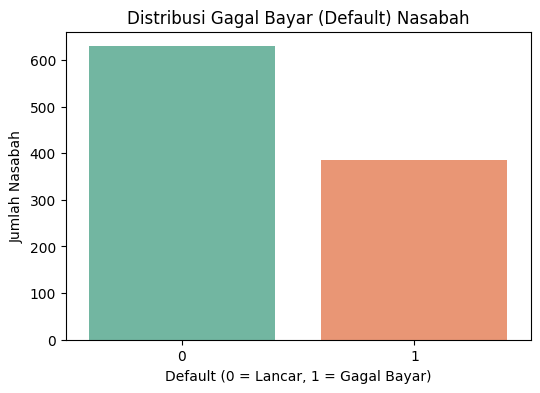

In [7]:
# Visualisasi Distribusi Target (Default)
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df, palette='Set2')
plt.title('Distribusi Gagal Bayar (Default) Nasabah')
plt.xlabel('Default (0 = Lancar, 1 = Gagal Bayar)')
plt.ylabel('Jumlah Nasabah')
plt.show()

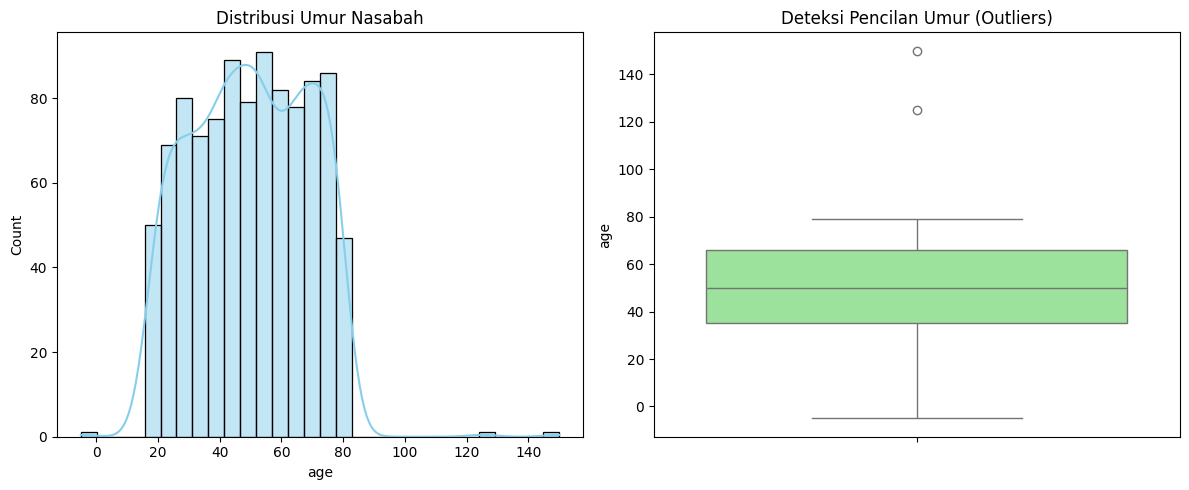

In [8]:
# Visualisasi Distribusi Umur dan Cek Pencilan
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribusi Umur Nasabah')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'], color='lightgreen')
plt.title('Deteksi Pencilan Umur (Outliers)')
plt.tight_layout()
plt.show()

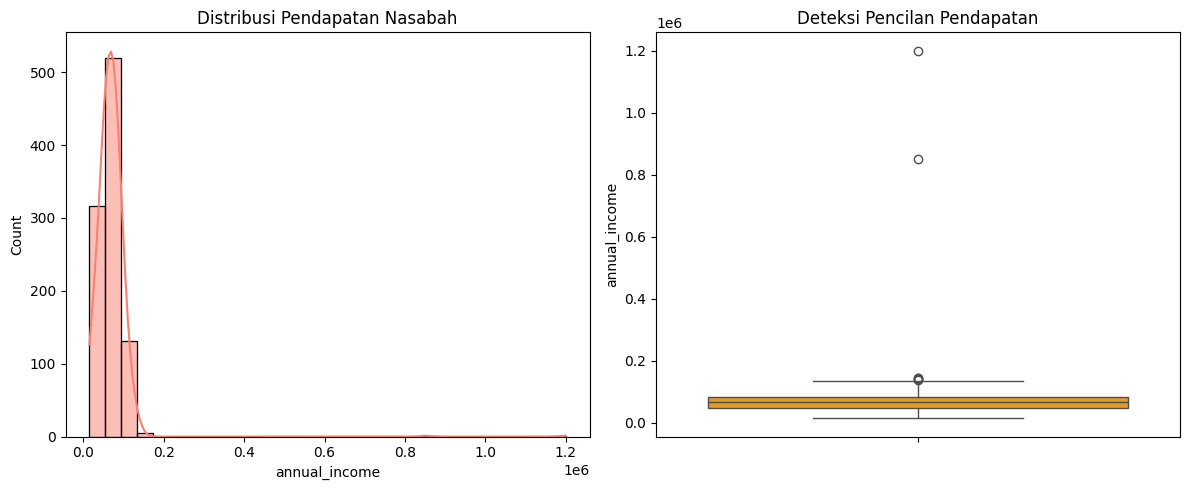

In [9]:
# Visualisasi Pendapatan Tahunan dan Cek Pencilan
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['annual_income'].dropna(), bins=30, kde=True, color='salmon')
plt.title('Distribusi Pendapatan Nasabah')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['annual_income'], color='orange')
plt.title('Deteksi Pencilan Pendapatan')
plt.tight_layout()
plt.show()

### Analisis Korelasi
Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik dan target variable . Nilai mendekati 1 atau -1 menunjukkan korelasi yang kuat, sedangkan nilai mendekati 0 menunjukkan korelasi lemah.

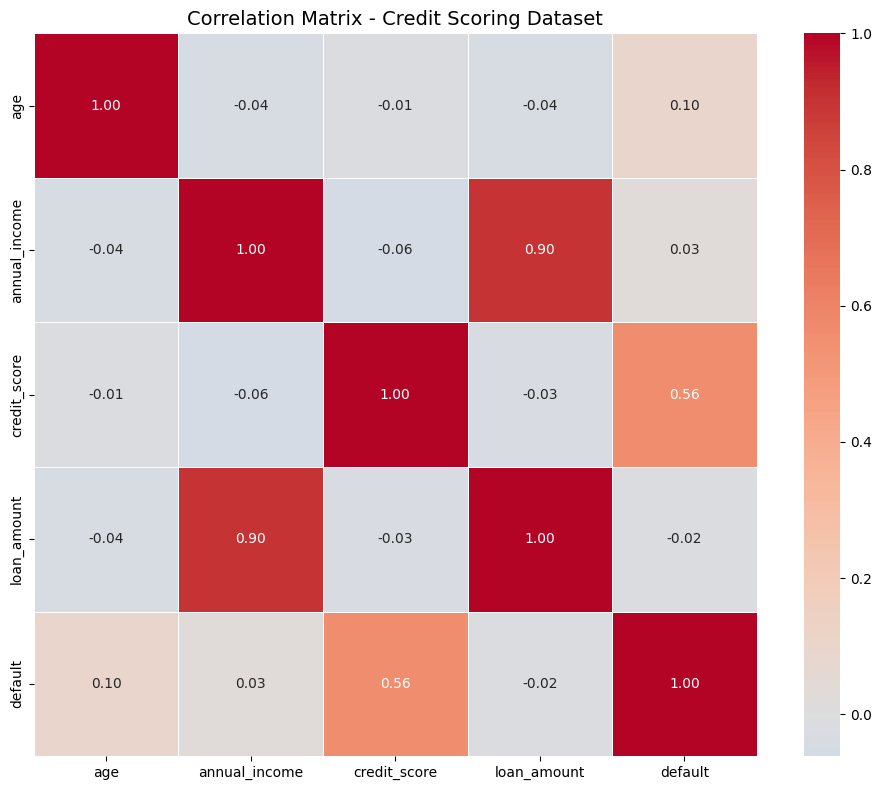

Fitur dengan korelasi tertinggi dengan target (default):
default          1.000000
credit_score     0.556814
age              0.098470
annual_income    0.032424
loan_amount     -0.015550
Name: default, dtype: float64


In [10]:
# Heatmap Korelasi antar Fitur Numerik
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=["number"])
correlation_matrix = numeric_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix - Credit Scoring Dataset", fontsize=14)
plt.tight_layout()
plt.show()
print("Fitur dengan korelasi tertinggi dengan target (default):")
print(correlation_matrix["default"].sort_values(ascending=False))

## 5. Data Preprocessing
Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi tidak terbatas pada:
- Menghapus atau Menangani Data Kosong (Missing Values)
- Menghapus Data Duplikat
- Normalisasi atau Standarisasi Fitur
- Deteksi dan Penanganan Outlier
- Encoding Data Categorical
- Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
# Step 1: Menghapus Data Duplikat
df_cleaned = df.drop_duplicates().copy()
print(f"Ukuran dataset setelah menghapus duplikat: {df_cleaned.shape[0]} baris")

Ukuran dataset setelah menghapus duplikat: 1000 baris


In [12]:
# Step 2: Menangani Data Kosong (Missing Values)
# Imputasi fitur numerik dengan nilai median
df_cleaned['age'] = df_cleaned['age'].fillna(df_cleaned['age'].median())
df_cleaned['annual_income'] = df_cleaned['annual_income'].fillna(df_cleaned['annual_income'].median())

# Imputasi fitur kategorikal dengan nilai modus
df_cleaned['marital_status'] = df_cleaned['marital_status'].fillna(df_cleaned['marital_status'].mode()[0])

print("Jumlah data kosong setelah imputasi:")
print(df_cleaned.isnull().sum())

Jumlah data kosong setelah imputasi:
customer_id        0
age                0
annual_income      0
credit_score       0
loan_amount        0
marital_status     0
education_level    0
default            0
dtype: int64


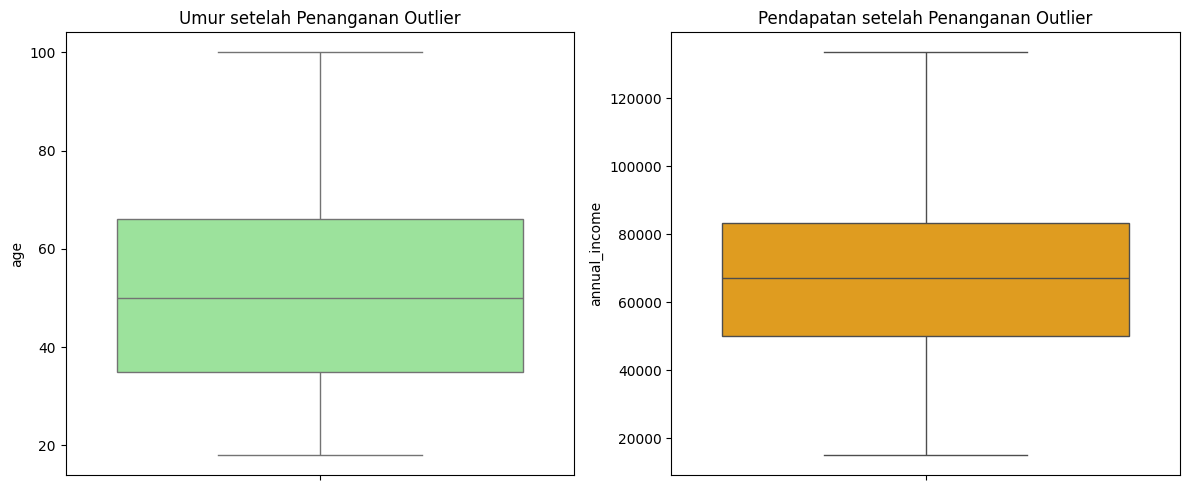

In [13]:
# Step 3: Deteksi dan Penanganan Outlier menggunakan Metode IQR
# Batasi outlier Umur
q1_age = df_cleaned['age'].quantile(0.25)
q3_age = df_cleaned['age'].quantile(0.75)
iqr_age = q3_age - q1_age
lower_age = max(18, q1_age - 1.5 * iqr_age)  # Umur minimal 18 tahun
upper_age = min(100, q3_age + 1.5 * iqr_age) # Batasi maksimal 100 tahun
df_cleaned['age'] = df_cleaned['age'].clip(lower_age, upper_age)

# Batasi outlier Pendapatan Tahunan
q1_inc = df_cleaned['annual_income'].quantile(0.25)
q3_inc = df_cleaned['annual_income'].quantile(0.75)
iqr_inc = q3_inc - q1_inc
lower_inc = q1_inc - 1.5 * iqr_inc
upper_inc = q3_inc + 1.5 * iqr_inc
df_cleaned['annual_income'] = df_cleaned['annual_income'].clip(lower_inc, upper_inc)

# Visualisasi setelah pembersihan outlier
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['age'], color='lightgreen')
plt.title('Umur setelah Penanganan Outlier')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['annual_income'], color='orange')
plt.title('Pendapatan setelah Penanganan Outlier')
plt.tight_layout()
plt.show()

In [14]:
# Step 4: Binning (Pengelompokan Data Umur)
# Mengelompokkan umur menjadi Young (18-35), Middle-Aged (36-55), Senior (56+)
bins = [17, 35, 55, np.inf]
labels = ['Young', 'Middle-Aged', 'Senior']
df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=bins, labels=labels)
print("Distribusi kelompok umur:")
print(df_cleaned['age_group'].value_counts())

Distribusi kelompok umur:
age_group
Senior         393
Middle-Aged    354
Young          253
Name: count, dtype: int64


In [15]:
# Step 5: Encoding Data Kategorikal (One-hot encoding)
# Drop customer_id karena tidak memiliki nilai prediktif
df_preprocessed = df_cleaned.drop(columns=['customer_id'])
categorical_cols = ['marital_status', 'education_level', 'age_group']
df_preprocessed = pd.get_dummies(df_preprocessed, columns=categorical_cols, drop_first=True)

# Mengonversi kolom boolean hasil dummy ke integer
bool_cols = df_preprocessed.select_dtypes(include=['bool']).columns
df_preprocessed[bool_cols] = df_preprocessed[bool_cols].astype(int)

print("Tampilan data setelah One-hot Encoding:")
df_preprocessed.head()

Tampilan data setelah One-hot Encoding:


,age,annual_income,credit_score,loan_amount,default,marital_status_Married,marital_status_Single,education_level_High School,education_level_Master,education_level_PhD,age_group_Middle-Aged,age_group_Senior
0,54.0,52003.665211,374,23300.0,0,0,1,0,0,1,1,0
1,63.0,56014.068149,442,24300.0,0,0,1,0,0,0,0,1
2,67.0,67878.794976,684,22300.0,1,1,0,0,0,0,0,1
3,36.0,68005.640836,612,33900.0,1,1,0,0,0,0,1,0
4,22.0,27830.730432,565,9800.0,0,1,0,1,0,0,0,0


In [16]:
# Step 6: Standarisasi Fitur Numerik
numerical_cols = ['age', 'annual_income', 'credit_score', 'loan_amount']
scaler = StandardScaler()
df_preprocessed[numerical_cols] = scaler.fit_transform(df_preprocessed[numerical_cols])

print("Tampilan data final hasil standarisasi:")
df_preprocessed.head()

Tampilan data final hasil standarisasi:


,age,annual_income,credit_score,loan_amount,default,marital_status_Married,marital_status_Single,education_level_High School,education_level_Master,education_level_PhD,age_group_Middle-Aged,age_group_Senior
0,0.227209,-0.577061,-1.305134,0.119124,0,0,1,0,0,1,1,0
1,0.727546,-0.418877,-0.877471,0.174337,0,0,1,0,0,0,0,1
2,0.949918,0.049108,0.644508,0.063910,1,1,0,0,0,0,0,1
3,-0.773466,0.054111,0.191688,0.704389,1,1,0,0,0,0,1,0
4,-1.551768,-1.530523,-0.103903,-0.626261,0,1,0,1,0,0,0,0


In [17]:
# Menyimpan dataset hasil preprocessing
output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'credit_scoring_preprocessing.csv')
df_preprocessed.to_csv(output_path, index=False)
print(f"Preprocessed dataset berhasil disimpan di: {output_path}")
print(f"Dimensi data final: {df_preprocessed.shape[0]} baris, {df_preprocessed.shape[1]} kolom")

Preprocessed dataset berhasil disimpan di: namadataset_preprocessing\credit_scoring_preprocessing.csv
Dimensi data final: 1000 baris, 12 kolom
